# FIFA 2026 Player Performance

*  DSC 530
*  Final
*  Saebastion Cole
*  Chosen Data Source: FIFA 2026 Player Performance

## Table of Contents

- [Dataset Selection Reasoning](#dataset-selection-reasoning)
- [Setup](#setup)
    - [Imports](#imports)
    - [Read Data](#read-data)
- [Dataset Selection](#dataset-selection)
- [Data Preperation](#data-preperation)
    - [Handle Missing Data / Cleaning](#handle-missing-data--cleaning)
    - [Re-encode variables](#re-encode-variables)
        - [Convert Match Date to Object](#convert-match-date-to-object)
        - [Set the index](#set-the-index)
    - [Data Transformation / Remove Skewness](#data-transformation--remove-skewness)
        - [Remove players that did not participate](#remove-players-that-did-not-participate)
    - [Normalization](#normalization)
- [Exploratory Data Analysis (EDA)](#exploratory-data-analysis-eda)
    - [1. Describe the Variable Characteristics with Summary](#1-describe-the-variable-characteristics-with-summary)
    - [2. Conduct Univariate Analysis](#2-conduct-univariate-analysis)
        - [Summary Statistics](#1-describe-the-variable-characteristics-with-summary-statistics)
        - [b. Create visualization of the key variables](#b-create-visualization-of-the-key-variables-to-examine-distribution-or-patterns)
    - [3. Conduct Bivariate Analysis](#3-conduct-bivariate-analysis)
        - [a. Calculate covariance and correlation](#a-calculate-covariance-and-correlation)
        - [b. Create visualization](#b-create-visualization)
    - [4. Test Statistics](#4-test-statistics)
    - [5. Regression and Classification](#5-regression-and-classification)
        - [a. Regression Analysis](#a-regression-analysis)
        - [b. Classification Model](#b-classification-model)
    - [6. Advanced Analysis Techniques](#6-advanced-analysis-techniques)
        - [a. Clustering Analysis](#a-clustering-analysis)
        - [b. Machine Learning approach to Regression or Classification](#b-machine-learning-approach-to-regression-or-classification)

## Dataset Selection Reasoning
With the end of the 2026 FIFA World Cup this data set has been recently released. Metric tracking is a huge part of sports especially international soccer. I chose this dataset to create new insights about player performance, roles, and reinforce some assumptions based on performance of players in higher regarded leagues compared to others.

The following are some of the analysis being reviewed:
- Are players that play on a career team in the UEFA champions league more impactful that a player that is not?
- Does the national team's climate and climate where the game took place play a part in the outcome?
- Where there any noticable outliers of positional play? (Did any players from one position do alot of another positions role in a game?)
- Does age effect movement (distance travelled).

## Setup

### Imports

In [99]:
# Begin by adding all of the needed imports at the top
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random as random

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import fowlkes_mallows_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestClassifier

from scipy import stats

### Read Data

In [100]:
# Read in the player stats data

player_stats = pd.read_csv("data/fifa_world_cup_2026_player_performance.csv")

player_stats.head()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


## Dataset Selection

This dataset from everything I have seen is very accurate and very complete. From the samples I have searched it contains the data for all of the games for the 2026 World Cup and all of the complete data for them. I have reviewed and seen no reason to believe there is bad data in it.

In [101]:
player_stats.info()

<class 'pandas.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  str    
 1   player_name               54600 non-null  str    
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  str    
 4   team                      54600 non-null  str    
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  str    
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  str    
 10  club_name                 54600 non-null  str    
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  str    
 13  match_date                54600 non-null  str    
 14  stadium          

## Data Preperation

### Handle Missing Data / Cleaning

Not much cleaning is required with this dataset since it already has been cleaned and seems complete, I reviewed and didn't see any duplicates or anything.

So since players wont be switching national teams we can assume if they play one game for one then they are playing for that team for all other games.

In [102]:
# Just to be safe remove any duplicates
player_stats = player_stats.drop_duplicates()

### Re-encode variables

Most values are already numeric and the ones that aren't can be inferred that they aren't meant to be like nationality and team name. I will only add a column for the date of game to be a data time object.

#### Convert Match Date to Object


In [103]:
# Convert the match_date column to a datetime object
player_stats["match_date_obj"] = pd.to_datetime(player_stats["match_date"], format="%Y-%m-%d")

# Sort the dataset
player_stats = player_stats.sort_values(by="match_date_obj")

player_stats["match_date_obj"].head()

6317    2026-06-11
23907   2026-06-11
23906   2026-06-11
23905   2026-06-11
23904   2026-06-11
Name: match_date_obj, dtype: datetime64[us]

#### Set the index
Index is player and match IDs combined since no player should have multiple records for a match. Doing this will help lookup speeds and overall processing of the dataset.

In [104]:
# Create an index for the pair to help with filtering speed
player_stats.set_index(["player_name", "match_id"], inplace=True)
player_stats.head()

,,player_id,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,club_name,...,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating,match_date_obj
player_name,match_id,,,,,,,,,,,,,,,,,,,,,
Giovanni Weah,M00122,P00653,33,American,United States,3,Goalkeeper,189,77,Right,LAFC,...,46.5,47.5,39.3,72.1,0,0,118,0,0.0,2026-06-11
Selim Saiss,M00460,P01060,21,Moroccan,Morocco,20,Midfielder,186,82,Right,Al-Hilal Omdurman,...,96.3,60.3,99.0,43.5,0,0,88,0,7.7,2026-06-11
Nayef Saibari,M00460,P01055,24,Moroccan,Morocco,15,Midfielder,175,70,Right,ASEC Mimosas,...,51.9,44.8,50.4,50.7,0,0,150,0,5.7,2026-06-11
Noussair El Khannouss,M00460,P01050,23,Moroccan,Morocco,10,Defender,180,74,Left,Club Africain,...,38.2,44.4,63.7,71.3,0,0,257,0,5.5,2026-06-11
Achraf Amellah,M00460,P01053,24,Moroccan,Morocco,13,Midfielder,186,77,Left,JS Kabylie,...,46.6,40.8,68.3,62.7,0,3,354,0,5.8,2026-06-11


### Data Transformation / Remove Skewness

#### Remove players that did not participate
For this the data will be cleaned picking only the players who have more than 0 minutes in. The rationale for this is FIFA allows world cup teams to consist of 26 players; Meanwhile only 11 are ever playing at a given time. The 2026 World Cup only allowed for 3 substitutions in regular time so nearly half of all players would not participate or have any meaningful statistics that would drastically skew the outcomes.

In [105]:
# Get data for players who actually competed
player_stats_active = player_stats[player_stats["minutes_played"] > 0]

player_stats_active.head()

,,player_id,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,club_name,...,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating,match_date_obj
player_name,match_id,,,,,,,,,,,,,,,,,,,,,
Selim Saiss,M00460,P01060,21,Moroccan,Morocco,20,Midfielder,186,82,Right,Al-Hilal Omdurman,...,96.3,60.3,99.0,43.5,0,0,88,0,7.7,2026-06-11
Nayef Saibari,M00460,P01055,24,Moroccan,Morocco,15,Midfielder,175,70,Right,ASEC Mimosas,...,51.9,44.8,50.4,50.7,0,0,150,0,5.7,2026-06-11
Noussair El Khannouss,M00460,P01050,23,Moroccan,Morocco,10,Defender,180,74,Left,Club Africain,...,38.2,44.4,63.7,71.3,0,0,257,0,5.5,2026-06-11
Achraf Amellah,M00460,P01053,24,Moroccan,Morocco,13,Midfielder,186,77,Left,JS Kabylie,...,46.6,40.8,68.3,62.7,0,3,354,0,5.8,2026-06-11
Romain Aboukhlal,M00460,P01054,18,Moroccan,Morocco,14,Midfielder,183,85,Right,TP Mazembe,...,67.0,99.0,83.4,71.0,2,1,456,0,6.0,2026-06-11


Cleaning the data further I will remove goalies from the data this will be used later for field player calculations.

In [106]:
player_stats_unique = (
      player_stats_active
      .reset_index()
      .drop_duplicates(subset="player_id")
      .set_index("player_id")
  )

## Exploratory Data Analysis (EDA) 

For my Analysis on this data I will focus on a few main points based on what is being analyzed. One of the core ratings I will be using is the player_rating. This is a value from 0-10 that helps quantify the impact the player had in the game and their overall performance. Alongside that I will focus on values like their club teams, their career income, age, and position. With focusing on some of these I should be able to filter out other features like shots (a goalie is not making shots on goal) and other more meaningful application.

#### 1.	Describe the Variable Characteristics with Summary 

- player_name: The name of the player
- player_rating: The calculated score of the player's performance that game.
- position: The position the player plays on the field (Like Striker, Midfield, Defender, and Goalie)
- club_name: This is the name of the team the player plays professionally for (This is seperate than an interanational team).
- market_value_eur: The estimated value of the player in euros.
- city: The city in which the World Cup game took place.
- match_result: the outcome of the game.
- distance_covered_km: How far the player moved in the game.
 

#### 2.	Conduct Univariate Analysis 

For this I am going to be somewhat selective on what I pick for each approach since there are a ton of features in this data set.

##### 1.	Describe the Variable Characteristics with Summary Statistics  

Player Rating Mean with / without players without time

In [107]:
# Calculate the average player rating

player_stats["player_rating"].mean()

np.float64(3.634699633699634)

In [108]:
player_stats_active["player_rating"].mean()

np.float64(6.288567082831612)

The comparison shows how much the scores get skewed by leaving in the players with time. 

Player Rating Median with / without players without time

In [109]:
# Calculate the average player rating

player_stats["player_rating"].median()

np.float64(5.5)

In [110]:
# Calculate the average player rating

player_stats_active["player_rating"].median()

np.float64(6.3)

Even with using an approach that should help handle the skewed values it still is showing how much it gets effected.

Distance Covered Mean/Median

Distance Covered Mean

In [111]:
player_stats_active["distance_covered_km"].mean()

np.float64(6.9145414791811906)

In [112]:
player_stats_active["distance_covered_km"].median()

np.float64(7.5)

I am calculating mean and median together as I believe they compliment each other closely to make sense of the data. By looking at the distance covered we can see a higher median than mean. This tells me that were are outliers that are bringing the average down. This would make sense because of substitutions where players don't get enough time to run as much as well as goal keepers. Each team has a position that is moving very little.

##### Mode

Most Common Player Rating

In [113]:
player_stats_active["player_rating"].value_counts().head(1)

player_rating
6.3    1760
Name: count, dtype: int64

Most Common Club Team

In [114]:
player_stats_active["club_name"].value_counts().head(1)

club_name
Gor Mahia    540
Name: count, dtype: int64

Most Common Age

In [115]:
player_stats_active["age"].value_counts().head(1)

age
24    3111
Name: count, dtype: int64

Most Common Position

In [116]:
player_stats_active["position"].value_counts().head(1)

position
Defender    11484
Name: count, dtype: int64

Player Rating Variance

In [117]:
# Measure how spread out the player ratings are
player_stats_active["player_rating"].var()

np.float64(0.5418460247642566)

This tells me that majority of this feature is pretty normalized. Most of the data is contained nearby itself.

#### Skewness

Player Rating Skewness

In [118]:
# Measure how symmetric the distribution is
player_stats_active["player_rating"].skew()

np.float64(0.14284556881610416)

Market Value Skewness

In [119]:
player_stats_active["market_value_eur"].skew()

np.float64(2.957217826947612)

The player rating skewness isn't very significant. Meanwhile the Market value skewness is very skewed to the right. This is to be expected because of two reasons. We are evaluating for each player for each game and not making it unique to a player so this will make those signals much stronger. Also for Players like Cristiano Ronaldo and Lionel Messi they are paid much more than an average player.

Player Rating Kurtosis

In [120]:
# Measure how heavy the tails are compared to a normal distribution
player_stats_active["player_rating"].kurt()

np.float64(0.01287081014658309)

Kurtosis being so small is reinforcing my thought about the ratings being a very normal dataset. It definitely has outliers but most players can be considered "average" by World Cup standards (obviously any player at this level is well above average).

##### b.	Create visualization of the key variables to examine distribution or patterns 

Visualization of the player_ratings

<Axes: ylabel='Frequency'>

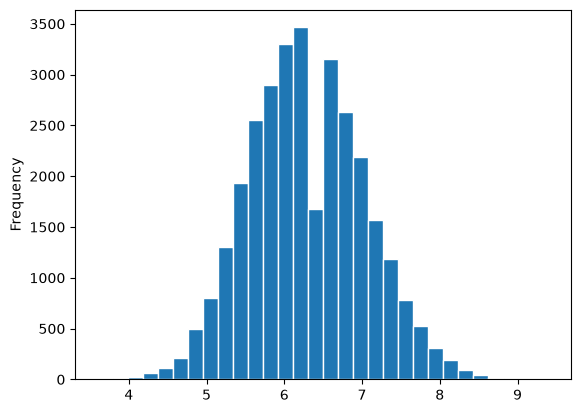

In [121]:
player_stats_active["player_rating"].plot(kind="hist", bins=30, edgecolor="white")

This is a very normalized value as I have already discussed by calculating the statistics.

Visualization of market value

<Axes: ylabel='Frequency'>

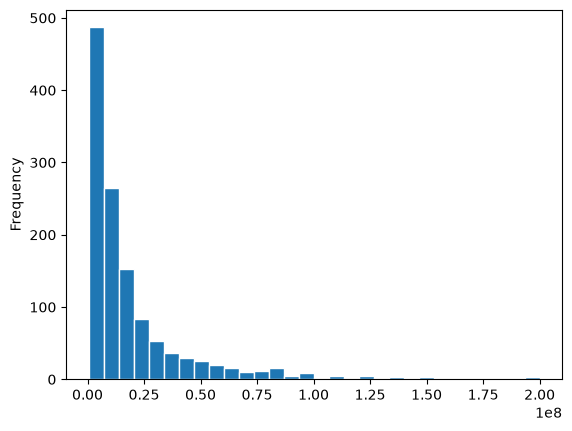

In [122]:
player_stats_unique["market_value_eur"].plot(kind="hist", bins=30, edgecolor="white")

As expected this is much less normal it has a hard skew right because you cannot go left (it is unlikely it is pay-to-play). And top players are very valuable.

<Axes: ylabel='Frequency'>

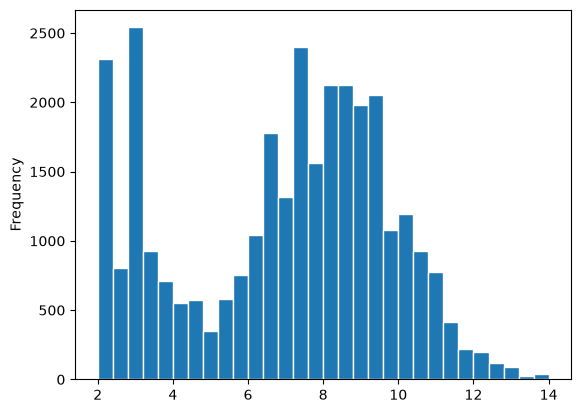

In [123]:
player_stats_active["distance_covered_km"].plot(kind="hist", bins=30, edgecolor="white")

A goal keepers main goal is to protect it that is why it makes sense why there are players who are not running the field.

#### 3.	Conduct Bivariate Analysis  

##### a.	Calculate covariance and correlation 

I will be calculating the correlation between Age and distance travelled. For this I will exclude Goal Keepers as this will skew results.

In [124]:
player_stats_active_field = player_stats_active[player_stats_active["position"] != "Goalkeeper"]
cols = ["age", "distance_covered_km"]
player_stats_active_field[cols].corr()

,age,distance_covered_km
age,1.000000,-0.020685
distance_covered_km,-0.020685,1.000000


The values are very small meaning there is little to no correlation.

I will look at another correlation to check if pay has anything to do with performance.

In [125]:
cols = ["player_rating", "market_value_eur"]
rating_corr = player_stats_active[cols].corr()
rating_corr

,player_rating,market_value_eur
player_rating,1.000000,0.409886
market_value_eur,0.409886,1.000000


A score of .4 shows a moderate correlation between performance and pay. The better the player the more money they get.

##### b.	Create visualization 

<Axes: >

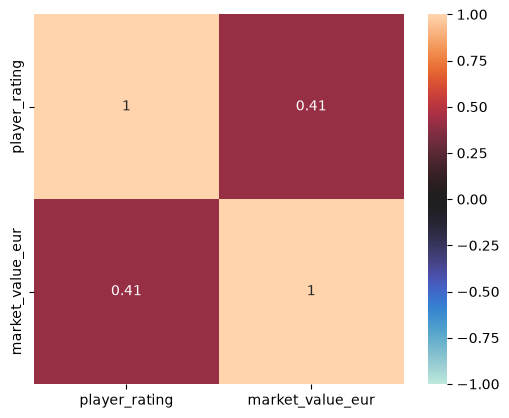

In [126]:
sns.heatmap(
    rating_corr,
    annot=True,
    center=0,
    vmin=-1,
    vmax=1,
    square=True
)

#### 4.	Test Statistics  

a.	Develop a hypothesis and select the appropriate test statistics based on your data. 

My hypothesis is that if a player is in the UEFA Champions League for career play they will have a higher player rating along side of making more money.

b.	For each test (e.g., t-test, F-test, Chi-squared), be sure to discuss the assumptions and whether they hold for your dataset 


Assumptions for each test and whether they hold here:

t test: Expects roughly normal data, independent observations and similar variances between the groups. Normality holds well, the univariate analysis showed a skew of 0.14 and an excess kurtosis of 0.01 for player_rating, which is about as close to normal as real data gets. Equal variance is not assumed because Welch's version is used below. Independence is the assumption that does not fully hold, since each player contributes one row per match rather than a single row.

F test: Carries the same assumptions as the t test. With two groups it is mathematically equivalent to it, so it is included to satisfy the requirement rather than because it adds new information.

Chi squared: Needs categorical variables and an expected count of at least five in every cell. Player rating is continuous, so it is binned into Low, Average and High bands. With tens of thousands of rows split across six cells, the expected count rule is comfortably met.

In [127]:
# Clubs in the UEFA Champions League, spelled the way this dataset spells them
ucl_clubs = [
    "Arsenal", "Aston Villa", "Atletico Madrid", "Barcelona", "Bayern Munich",
    "Borussia Dortmund", "Club Brugge", "Como", "Feyenoord", "Galatasaray",
    "Inter Milan", "Lens", "Lille", "Liverpool", "Manchester City",
    "Manchester United", "Napoli", "Paris Saint-Germain", "Porto",
    "PSV Eindhoven", "RB Leipzig", "Real Betis", "Real Madrid", "Roma",
    "Shakhtar Donetsk", "Slavia Praha", "Sporting CP", "Stuttgart", "Villarreal",
]

# Barcelona SC is an Ecuadorian club and is not FC Barcelona, so this matches exactly
# rather than searching for substrings. Anything listed below never matched a club in
# the data and needs its spelling checked before the results can be trusted.
[club for club in ucl_clubs if club not in set(player_stats_active["club_name"])]

['Aston Villa',
 'Como',
 'Lens',
 'Lille',
 'Real Betis',
 'Shakhtar Donetsk',
 'Slavia Praha',
 'Stuttgart',
 'Villarreal']

In [128]:
in_ucl = player_stats_active["club_name"].isin(ucl_clubs)

ucl_ratings = player_stats_active.loc[in_ucl, "player_rating"]
other_ratings = player_stats_active.loc[~in_ucl, "player_rating"]

pd.DataFrame({
    "group": ["Champions League", "Everyone else"],
    "count": [ucl_ratings.count(), other_ratings.count()],
    "mean_rating": [ucl_ratings.mean(), other_ratings.mean()],
    "std_rating": [ucl_ratings.std(), other_ratings.std()],
})

,group,count,mean_rating,std_rating
0,Champions League,4491,6.252594,0.738885
1,Everyone else,27067,6.294536,0.735483


In [129]:
ucl_ratings.mean()

np.float64(6.252594077042975)

This mean is lower than the actual average.

In [130]:
# Welch's t test, which does not assume the two groups share the same variance
stats.ttest_ind(ucl_ratings, other_ratings, equal_var=False)

TtestResult(statistic=np.float64(-3.5252540167217505), pvalue=np.float64(0.00042620299194004284), df=np.float64(6060.464882836474))

In [131]:
# One way ANOVA. With only two groups the F statistic is the t statistic squared
stats.f_oneway(ucl_ratings, other_ratings)

F_onewayResult(statistic=np.float64(12.509741580089008), pvalue=np.float64(0.0004054161108670679))

In [132]:
# Chi squared works on categories, so the ratings get binned into three bands
rating_band = pd.cut(
    player_stats_active["player_rating"],
    bins=[0, 5.5, 7.0, 10],
    labels=["Low", "Average", "High"],
    include_lowest=True,
)

# crosstab aligns its inputs on the index, and the player_name / match_id index is not
# unique, so the raw values are passed instead to skip the alignment step
contingency = pd.crosstab(
    in_ucl.to_numpy(),
    rating_band.to_numpy(),
    rownames=["in_ucl"],
    colnames=["rating_band"],
)

chi2, chi2_p, dof, expected = stats.chi2_contingency(contingency)

print(contingency)
print("\nchi2:", chi2, " p:", chi2_p, " dof:", dof)

rating_band  Average  High   Low
in_ucl                          
False          18764  4109  4194
True            3106   616   769

chi2: 12.026371206856105  p: 0.0024462828676099966  dof: 2


c.	Explain the test statistics results, interpret p-values and draw conclusion  

Results
All three tests returned p-values below .005 so we can reject the null hypthesis that there is no correlation between performance and pay. But the actual outcome is the opposite to what I would expect. The mean of the rating if the player is in the ucl is actually lower than the average of the rest. This is probably due to them getting targetting. Coaching staff is aware these players are considered some of the best and most likely tells teams to focus defending them more.

#### 5.	Regression and Classification 

##### a.	Regression Analysis 

i.	Select an appropriate regression model based on the variable selected.  



I am predicting player_rating, so this calls for a multiple linear regression rather than a classification model since the player_rating is a numeric value. The target is continuous on a 0 to 10 scale, and the univariate analysis showed it is very close to normal with a skewness of 0.14 and an excess kurtosis of 0.01. That is what makes a linear model appropriate here rather than just convenient, since linear regression assumes the errors are normally distributed.

The data is very complete so much so that I will be leaving out the columns that are based on accumulated features and aggregating data similar to how the player_rating itself is calculated.

ii.	Run the regression model and evaluate it with the performance metrics you’ve learned  


In [133]:
# Check the columns before modeling. Anything correlating close to 1 with
# player_rating is derived from it and would leak the answer into the model.
composites = [
    "performance_score",
    "offensive_contribution",
    "defensive_contribution",
    "possession_impact",
    "pressure_resistance",
    "creativity_score",
    "consistency_score",
    "clutch_performance_score",
    "stamina_score",
    "tournament_rating",
]

player_stats_active[composites + ["player_rating"]].corr()["player_rating"].sort_values()

clutch_performance_score    0.092819
stamina_score               0.121630
defensive_contribution      0.210760
creativity_score            0.266046
offensive_contribution      0.332765
possession_impact           0.369980
pressure_resistance         0.438209
consistency_score           0.462525
tournament_rating           0.924095
performance_score           0.926060
player_rating               1.000000
Name: player_rating, dtype: float64

In [134]:
# Raw match measurements and player attributes only, no composite scores
features = [
    "minutes_played",
    "distance_covered_km",
    "sprint_distance_km",
    "top_speed_kmh",
    "accelerations",
    "decelerations",
    "pass_accuracy",
    "successful_passes",
    "key_passes",
    "shots",
    "shots_on_target",
    "expected_goals_xg",
    "expected_assists_xa",
    "goals",
    "assists",
    "successful_dribbles",
    "tackles",
    "interceptions",
    "clearances",
    "blocks",
    "aerial_duels_won",
    "recoveries",
    "fouls_committed",
    "age",
    "market_value_eur",
    "height_cm",
    "weight_kg",
]

rating_X = pd.get_dummies(
    player_stats_active[features + ["position"]],
    columns=["position"],
    drop_first=True,
)

rating_y = player_stats_active["player_rating"]

rating_X.shape

(31558, 30)

In [135]:
X_train, X_test, y_train, y_test = train_test_split(
    rating_X, rating_y, train_size=0.75, random_state=42
)

rating_model = LinearRegression().fit(X_train, y_train)

# Predict on the test set so the model is scored on data it has not seen
rating_preds = rating_model.predict(X_test)

print("R2:", r2_score(y_test, rating_preds))

# mean_squared_error no longer takes the squared argument so I take the root myself
print("RMSE:", np.sqrt(mean_squared_error(y_test, rating_preds)))

# Guessing the mean every time is the benchmark RMSE to beat
print("Std dev of player_rating:", rating_y.std())

R2: 0.17002077350161937
RMSE: 0.6751058693190093
Std dev of player_rating: 0.7361019119417206


Text(0.5, 0.98, 'Residuals')

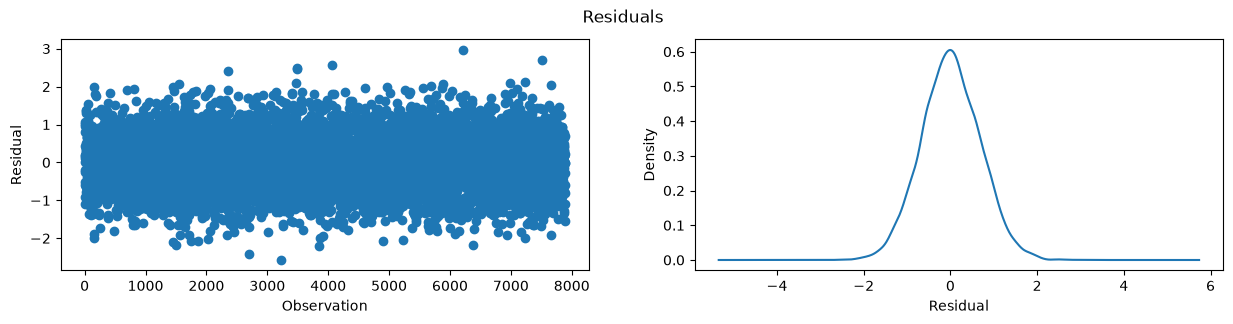

In [136]:
residuals = y_test - rating_preds

fig, axes = plt.subplots(1, 2, figsize=(15, 3))

axes[0].scatter(np.arange(residuals.shape[0]), residuals)
axes[0].set_xlabel("Observation")
axes[0].set_ylabel("Residual")

residuals.plot(kind="kde", ax=axes[1])
axes[1].set_xlabel("Residual")

plt.suptitle("Residuals")

iii.	Interpret your result 

Overall the model seems pretty accurate. This is somewhat to be expected since the data is normalized and includes pretty much every feature that would be needed.

##### b.	Classification Model  

For the classification model I am predicting whether a player performed above average for a given match.

Basing this off of the median instead of the mean to ignore skewness.

In [137]:
# The target is whether the player beat the median rating of 6.3 in that match
class_y = player_stats_active["player_rating"] > player_stats_active["player_rating"].median()

# Same regressors as the linear model, so player_rating itself is never fed to the model
class_X = rating_X

class_X_train, class_X_test, class_y_train, class_y_test = train_test_split(
    class_X, class_y, test_size=0.25, random_state=42, stratify=class_y
)

# Scaling matters here because market_value_eur runs into the millions while
# pass_accuracy is a percentage, and logistic regression will not converge otherwise.
class_model = Pipeline([
    ("scale", StandardScaler()),
    ("logistic", LogisticRegression(random_state=42, max_iter=1000)),
]).fit(class_X_train, class_y_train)

class_preds = class_model.predict(class_X_test)

print("Class balance:")
print(class_y.value_counts())
print("\nAccuracy:", accuracy_score(class_y_test, class_preds))

Class balance:
player_rating
False    17179
True     14379
Name: count, dtype: int64

Accuracy: 0.6870722433460076


In [138]:
# The classification report gives the precision, recall and F1 score for each class.

print(classification_report(
    class_y_test, class_preds, target_names=["below average", "above average"]
))

               precision    recall  f1-score   support

below average       0.67      0.83      0.74      4295
above average       0.72      0.51      0.60      3595

     accuracy                           0.69      7890
    macro avg       0.70      0.67      0.67      7890
 weighted avg       0.69      0.69      0.68      7890



Text(0.5, 0, 'AUC: 0.73')

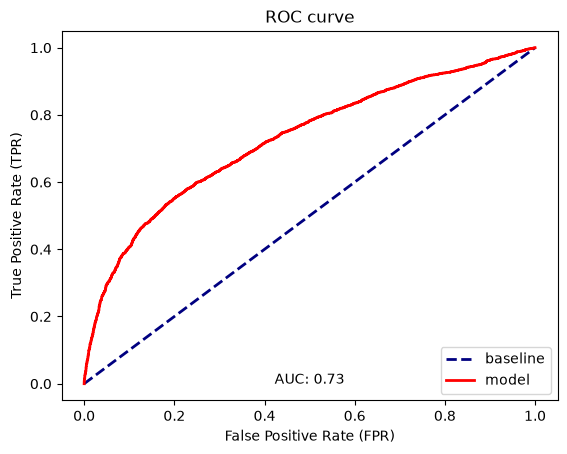

In [139]:
class_probs = class_model.predict_proba(class_X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(class_y_test, class_probs)

fig, ax = plt.subplots(1, 1)

# The diagonal is what random guessing would look like.
ax.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="baseline")
ax.plot(fpr, tpr, color="red", lw=2, label="model")

ax.legend(loc="lower right")
ax.set_title("ROC curve")
ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")

# The area under the curve tells me how much better than the baseline the model is.
ax.annotate(f"AUC: {auc(fpr, tpr):.2}", xy=(0.5, 0), horizontalalignment="center")

Text(0.5, 1.0, 'Confusion Matrix')

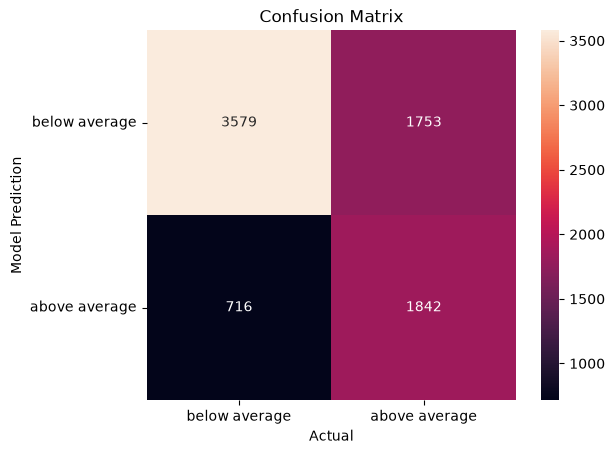

In [140]:
matrix = confusion_matrix(class_y_test, class_preds)

# Put predictions on the y axis and the actual values on the x axis.
ax = sns.heatmap(matrix.T, square=True, annot=True, fmt="d")

ax.set_xlabel("Actual")
ax.set_ylabel("Model Prediction")

class_labels = ["below average", "above average"]
ax.set_xticklabels(class_labels)
ax.set_yticklabels(class_labels, rotation=0)

ax.set_title("Confusion Matrix")

I chose to use the median so we can cleanly split the two groups into two sizes that will help for modeling. As for the grouping it is pretty cut and dry, if it is above half it is above average.

#### 6.	Advanced Analysis Techniques

##### a.	Clustering Analysis

i.	Select an appropriate clustering method for your data, and consider including dimensionality reduction (e.g., PCA) to visualize the clusters especially in high-dimensional spaces.

I am using k-means, the same method applied to the wine data in the week 9 and 10 assignment. It suits this data because all of the data are numeric and k-means works on straight line distance between points, and because there is a sensible guess available for how many groups to expect.

The features are scaled first inside a pipeline this is to help reduce noise that would be caused with the high numbers in things like the player salaries.

For the number of clusters I am using k = 4 to match the four positions in the data. 

Text(0.5, 1.0, 'Choosing the number of clusters')

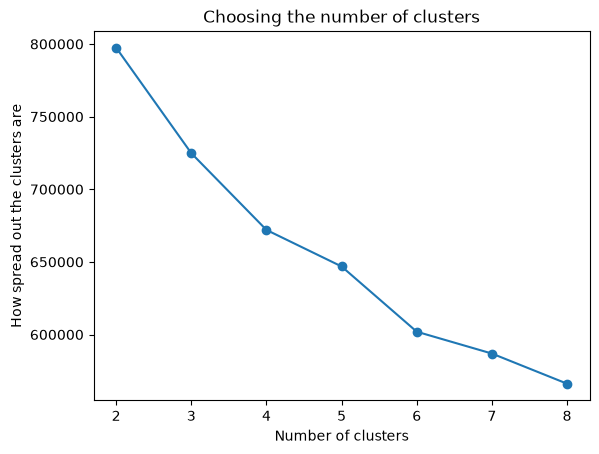

In [141]:
# Scale once, then try a few different numbers of clusters
scaled_features = StandardScaler().fit_transform(rating_X)

spread = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(scaled_features)
    spread.append(kmeans.inertia_)

plt.plot(range(2, 9), spread, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("How spread out the clusters are")
plt.title("Choosing the number of clusters")

In [142]:
# Four clusters, chosen to match the four positions so the grouping can be checked
# against something real instead of only being described.
cluster_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=4, random_state=42)),
]).fit(rating_X)

clusters = cluster_pipeline.named_steps["kmeans"].labels_

pd.Series(clusters).value_counts().sort_index()

0    10119
1     5423
2     8774
3     7242
Name: count, dtype: int64

Variance kept by the two components: 0.32750050584652834


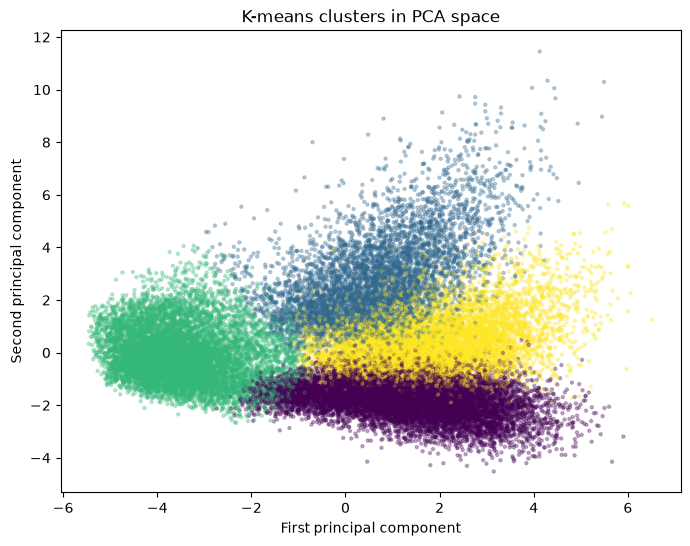

In [143]:
pca = PCA(n_components=2, random_state=42)

coords = pca.fit_transform(StandardScaler().fit_transform(rating_X))

plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=clusters, cmap="viridis", s=5, alpha=0.3)
plt.xlabel("First principal component")
plt.ylabel("Second principal component")
plt.title("K-means clusters in PCA space")

print("Variance kept by the two components:",
      pca.explained_variance_ratio_.sum())

ii.	Evaluate the model and interpret the grouping of data based on the result

In [144]:
# Fowlkes-Mallows compares the clustering against the real positions, the same way the
# wine clusters were checked against red vs white in the week 9 and 10 assignment.
print("Fowlkes-Mallows score vs position:",
      fowlkes_mallows_score(player_stats_active["position"], clusters))

pd.crosstab(
    player_stats_active["position"].to_numpy(),
    clusters,
    rownames=["position"],
    colnames=["cluster"],
)

Fowlkes-Mallows score vs position: 0.6220025980125204


cluster,0,1,2,3
position,,,,
Defender,8019,5,3360,100
Forward,32,5401,2267,0
Goalkeeper,2025,0,75,0
Midfielder,43,17,3072,7142


In [145]:
# What actually separates the clusters, shown as the average of each feature per cluster
profile_cols = [
    "minutes_played",
    "distance_covered_km",
    "sprint_distance_km",
    "pass_accuracy",
    "successful_passes",
    "shots",
    "tackles",
    "clearances",
    "aerial_duels_won",
    "market_value_eur",
    "age",
]

profiles = player_stats_active[profile_cols].copy()
profiles["cluster"] = clusters

profiles.groupby("cluster").mean().T

cluster,0,1,2,3
minutes_played,7.690770e+01,7.648110e+01,2.570344e+01,7.705081e+01
distance_covered_km,7.947821e+00,8.329135e+00,3.116788e+00,9.012635e+00
sprint_distance_km,9.109596e-01,9.599852e-01,3.768521e-01,1.037697e+00
pass_accuracy,8.001561e-01,7.807099e-01,8.190289e-01,8.491066e-01
successful_passes,3.079049e+01,2.145510e+01,1.083257e+01,4.442171e+01
shots,3.522087e-01,2.065646e+00,3.069296e-01,9.596796e-01
tackles,2.152980e+00,6.763784e-01,5.824026e-01,1.831124e+00
clearances,3.131139e+00,2.524433e-01,5.453613e-01,8.721348e-01
aerial_duels_won,1.977863e+00,1.284344e+00,5.076362e-01,1.278376e+00
market_value_eur,1.457478e+07,2.855203e+07,1.946776e+07,2.413155e+07


Minutes in do have a big part but also the role of the player has different tasks. A defender is not expected to take shots on goal instead more tackles along with winning more aerial duels. Strikers are widely known as the most paid role and this also shows.

##### b.	Machine Learning approach to Regression or Classification

i.	Apply a regression or classification model using machine learning approach. You can use the same set of variables from requirement number 5.

I am reusing the classification problem from section 5b, predicting whether a player beat the median rating of 6.3 in a given match, with the same regressors. Keeping the target and the features identical means the two models can be compared head to head and any difference in performance comes from the model itself rather than from a change in the data.

The model is a random forest. Section 5 already covered the linear and logistic models, so applying another one here would not show anything new. A random forest works differently in a way that matters for this data: it builds many decision trees on random subsets and averages them, which lets it capture relationships that are not straight lines and interactions between features that a logistic regression cannot represent. A defender with high pass accuracy and a forward with high pass accuracy may mean very different things for a rating, and a forest can learn that while a linear model cannot.

No scaling step is needed this time. Trees split on one feature at a time, so the units a variable is measured in make no difference to them.

In [146]:
# Same target and same regressors as section 5b so the two models can be compared
# directly. Trees split on one feature at a time so no scaling is needed here.
forest_model = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
).fit(class_X_train, class_y_train)

forest_preds = forest_model.predict(class_X_test)
forest_probs = forest_model.predict_proba(class_X_test)[:, 1]

print("Accuracy:", accuracy_score(class_y_test, forest_preds))

print()
print(classification_report(
    class_y_test, forest_preds, target_names=["below average", "above average"]
))

forest_fpr, forest_tpr, forest_thresholds = roc_curve(class_y_test, forest_probs)

print("AUC:", auc(forest_fpr, forest_tpr))

Accuracy: 0.6836501901140685

               precision    recall  f1-score   support

below average       0.68      0.79      0.73      4295
above average       0.69      0.55      0.61      3595

     accuracy                           0.68      7890
    macro avg       0.69      0.67      0.67      7890
 weighted avg       0.68      0.68      0.68      7890

AUC: 0.7259236975426677


Text(0.5, 1.0, 'Top 15 features by importance')

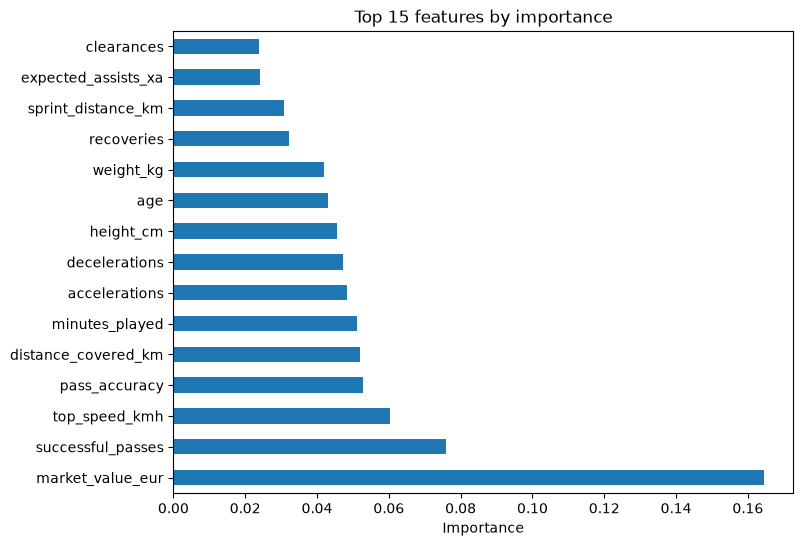

In [147]:
# Which regressors the forest actually leaned on when making its splits
pd.Series(
    forest_model.feature_importances_, index=class_X.columns
).sort_values(ascending=False).head(15).plot(kind="barh", figsize=(8, 6))

plt.xlabel("Importance")
plt.title("Top 15 features by importance")

ii.	Evaluate the model performance metrics and interpret the results


I ran the same metrics as the logistic model so the two can be compared directly. The random forest got 68.4% accuracy with an AUC of 0.726. The logistic regression got 68.7% accuracy with an AUC of 0.73.

They are essentially identical, and if anything the forest came out very slightly worse.

0.55 and 0.51 Both lean toward guessing below average, so neither is good at picking out standout performances.

An AUC around 0.73 is a weak confirmation, so the match statistics clearly carry information about the rating, just not enough to predict it reliably.